In [1]:
import pandas as pd
import glob

folder_path = "/Users/andrewgerardo/Documents/Divvy_Data"

files = glob.glob(folder_path + "/*.csv")

print(files)  # shows all files found

['/Users/andrewgerardo/Documents/Divvy_Data/202011-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202104-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202012-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202009-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202101-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202102-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202007-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202103-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202006-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202005-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202008-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202010-divvy-tripdata.csv']


In [2]:
print(len(files))

12


In [3]:
print(files[:3])

['/Users/andrewgerardo/Documents/Divvy_Data/202011-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202104-divvy-tripdata.csv', '/Users/andrewgerardo/Documents/Divvy_Data/202012-divvy-tripdata.csv']


In [4]:
df_list = []

for file in files:
    df = pd.read_csv(file)

    # Clean column names
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # Convert dates
    df["started_at"] = pd.to_datetime(df["started_at"])
    df["ended_at"] = pd.to_datetime(df["ended_at"])

    # Create ride length
    df["ride_length"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

    # Remove bad data
    df = df[df["ride_length"] > 0]
    df = df[df["ride_length"] <= 1440]

    # Add features
    df["day_of_week"] = df["started_at"].dt.day_name()
    df["month"] = df["started_at"].dt.month_name()
    df["hour"] = df["started_at"].dt.hour

    df_list.append(df)

final_df = pd.concat(df_list, ignore_index=True)
final_df.to_csv("cleaned_full_year.csv", index=False)

In [5]:
import pandas as pd

df = pd.read_csv("cleaned_full_year.csv")

/var/folders/z7/4dcbhsys3n169ss2n8h8bcdw0000gn/T/ipykernel_10435/1212450041.py:3: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_full_year.csv")


In [6]:
df = pd.read_csv("cleaned_full_year.csv", low_memory=False)

In [7]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_length', 'day_of_week', 'month', 'hour'],
      dtype='object')

In [8]:
df.iloc[:, [5,7]].head()

,start_station_id,end_station_id
0,110.0,211.0
1,672.0,29.0
2,76.0,41.0
3,659.0,185.0
4,2.0,2.0


In [9]:
df.dtypes

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
ride_length           float64
day_of_week            object
month                  object
hour                    int64
dtype: object

In [10]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

In [11]:
df.dtypes

ride_id                       object
rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
ride_length                  float64
day_of_week                   object
month                         object
hour                           int64
dtype: object

In [12]:
df[["started_at", "ended_at"]].head()

,started_at,ended_at
0,2020-11-01 13:36:00,2020-11-01 13:45:40
1,2020-11-01 10:03:26,2020-11-01 10:14:45
2,2020-11-01 00:34:05,2020-11-01 01:03:06
3,2020-11-01 00:45:16,2020-11-01 00:54:31
4,2020-11-01 15:43:25,2020-11-01 16:16:52


In [13]:
(df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

0           9.666667
1          11.316667
2          29.016667
3           9.250000
4          33.450000
             ...    
3728266     6.433333
3728267     8.600000
3728268    27.566667
3728269    20.183333
3728270    11.466667
Length: 3728271, dtype: float64

In [14]:
df.groupby("member_casual")["ride_length"].mean()

member_casual
casual    35.863649
member    15.439722
Name: ride_length, dtype: float64

In [15]:
df["member_casual"].value_counts()

member_casual
member    2190996
casual    1537275
Name: count, dtype: int64

In [16]:
df.groupby("day_of_week")["ride_length"].mean().sort_values()

day_of_week
Wednesday    20.609423
Thursday     20.913323
Tuesday      21.060838
Monday       22.271315
Friday       22.825451
Saturday     28.127595
Sunday       28.668897
Name: ride_length, dtype: float64

In [17]:
df.groupby("hour")["ride_length"].mean()

hour
0     32.239868
1     35.442989
2     35.675821
3     32.458449
4     23.590325
5     16.844851
6     15.807881
7     15.970142
8     16.894549
9     19.793487
10    23.214066
11    24.173921
12    24.491932
13    25.706278
14    26.515778
15    25.510280
16    24.082341
17    23.050117
18    23.205299
19    24.137437
20    25.469422
21    26.264944
22    27.687495
23    28.857436
Name: ride_length, dtype: float64

In [18]:
df.groupby("month")["ride_length"].mean()

month
April        21.228902
August       26.175137
December     14.903119
February     18.764439
January      14.311546
July         30.676247
June         29.153046
March        20.317535
May          30.242518
November     18.303086
October      18.673016
September    22.409720
Name: ride_length, dtype: float64

In [19]:
df.groupby("member_casual")["ride_length"].describe()

,count,mean,std,min,25%,50%,75%,max
member_casual,,,,,,,,
casual,1537275.0,35.863649,62.526402,0.016667,11.333333,20.816667,39.483333,1439.900000
member,2190996.0,15.439722,22.598476,0.016667,6.433333,11.316667,19.800000,1439.716667


In [20]:
df.groupby(["member_casual", "day_of_week"]).size()

member_casual  day_of_week
casual         Friday         228555
               Monday         164159
               Saturday       358133
               Sunday         280438
               Thursday       175976
               Tuesday        161727
               Wednesday      168287
member         Friday         334627
               Monday         286935
               Saturday       340841
               Sunday         278950
               Thursday       319197
               Tuesday        306991
               Wednesday      323455
dtype: int64

In [21]:
df.groupby("day_of_week")["ride_length"].mean().sort_values(ascending=False)

day_of_week
Sunday       28.668897
Saturday     28.127595
Friday       22.825451
Monday       22.271315
Tuesday      21.060838
Thursday     20.913323
Wednesday    20.609423
Name: ride_length, dtype: float64

In [22]:
df["hour"].value_counts().sort_index()

hour
0      38482
1      23258
2      12273
3       6987
4       7633
5      24521
6      73552
7     126125
8     144341
9     136546
10    160541
11    207970
12    248833
13    256572
14    263832
15    286684
16    327289
17    383750
18    339606
19    245422
20    159422
21    105812
22     85104
23     63716
Name: count, dtype: int64

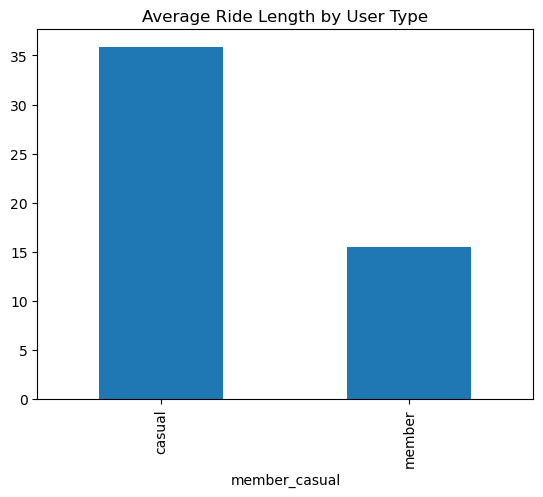

In [23]:
import matplotlib.pyplot as plt

df.groupby("member_casual")["ride_length"].mean().plot(kind="bar")
plt.title("Average Ride Length by User Type")
plt.show()

In [24]:
import matplotlib.pyplot as plt

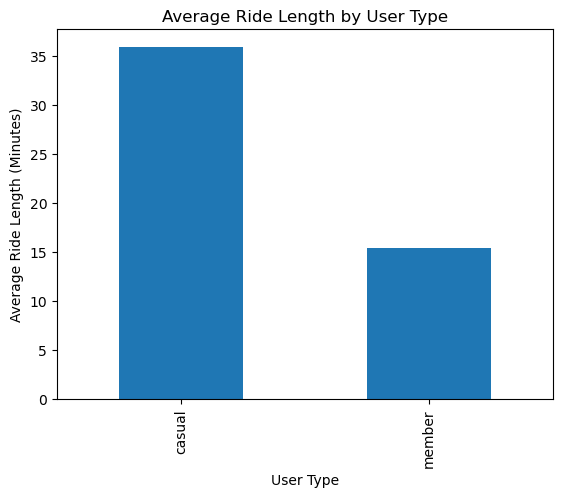

In [30]:
df.groupby("member_casual")["ride_length"].mean().plot(kind="bar")

plt.title("Average Ride Length by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Ride Length (Minutes)")

plt.savefig("avg_ride_length.png")

plt.show()

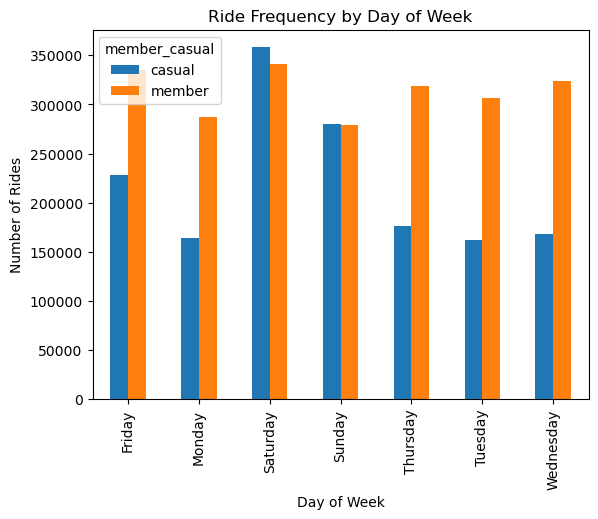

In [31]:
df.groupby(["day_of_week", "member_casual"]).size().unstack().plot(kind="bar")

plt.title("Ride Frequency by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")

plt.savefig("weekday_usage.png")

plt.show()

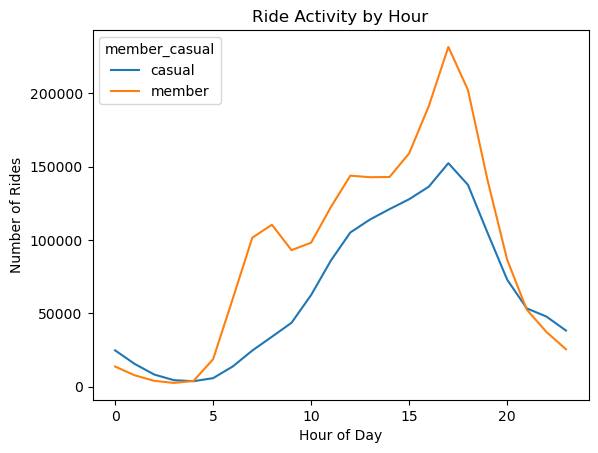

In [32]:
df.groupby(["hour", "member_casual"]).size().unstack().plot()

plt.title("Ride Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

plt.savefig("hourly_usage.png")

plt.show()

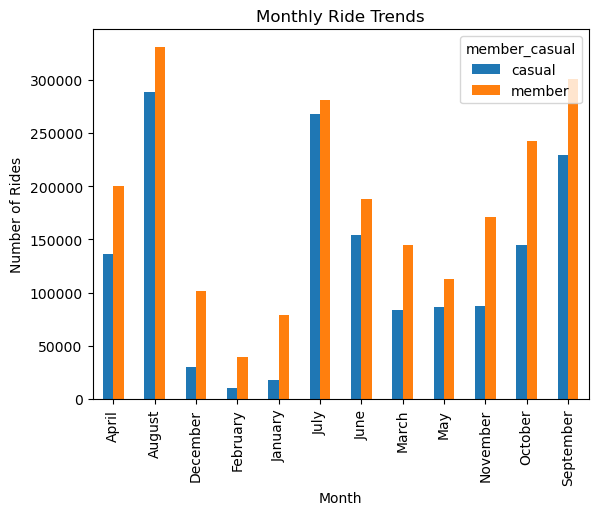

In [33]:
df.groupby(["month", "member_casual"]).size().unstack().plot(kind="bar")

plt.title("Monthly Ride Trends")
plt.xlabel("Month")
plt.ylabel("Number of Rides")

plt.savefig("monthly_trends.png")

plt.show()